# ① 第一階段：資料準備與探索 (Data Preparation & EDA)

本 Notebook 涵蓋專案計畫「① 第一階段：資料準備與探索」的內容，主要任務包含：

1.  **1.1 資料載入與初步檢視**: 
    *   讀取提供的 CSV/Parquet 歷史 Tick 資料。
    *   確認欄位名稱、資料型態、資料筆數、時間範圍。
2.  **1.2 資料清洗**: 
    *   處理缺失值 (NaN)。
    *   處理異常價格 (outliers)。
    *   處理重複資料。
    *   記錄清洗策略與過程。
3.  **1.3 時間序列處理**: 
    *   將 DataFrame 以時間欄位為索引。
    *   時間格式標準化。
    *   處理非交易時間資料 (若適用，例如過濾盤後交易或分開處理)。
4.  **1.4 初步探索性資料分析 (EDA)**: 
    *   價格 (開高低收) 走勢圖。
    *   成交量變化圖。
    *   基礎波動率分析 (e.g., 日報酬率標準差)。
    *   價格與成交量分佈圖。
5.  **1.5 技術指標特徵工程 (基礎)**: 
    *   計算並新增數個核心技術指標欄位 (e.g., SMA, EMA, RSI)。
    *   目標是選擇少量、易於理解的指標用於快速原型。
6.  **1.6 製作標註欄位 (Target Labeling)**: 
    *   新增目標預測欄位 (e.g., `target_price_up_N_ticks`)，值為 0/1 或 -1/0/1。
    *   明確定義預測目標 (e.g., 未來 N Tick/分鐘 後價格漲跌幅是否超過 X%)。

---

In [37]:
import os
import sys

# 將專案根目錄添加到 Python 搜尋路徑
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [38]:
from utils.data_loader import load_and_inspect_data

指定資料檔案路徑

In [39]:
data_path = '../data/raw/ticks_2025-04.parquet'
# data_path = '../data/raw/ticks_2025-0527.parquet'

載入資料並檢視

In [40]:
df = load_and_inspect_data(data_path)

資料載入成功！
前 5 行資料：
             ts    close  volume  bid_price  bid_volume  ask_price  \
0  1.743433e+18  20807.0    89.0        0.0         0.0        0.0   
1  1.743433e+18  20808.0     2.0    20807.0         5.0    20808.0   
3  1.743433e+18  20809.0     1.0    20807.0         5.0    20808.0   
5  1.743433e+18  20807.0     1.0    20807.0         5.0    20810.0   
6  1.743433e+18  20807.0     1.0    20807.0         6.0    20810.0   

   ask_volume  tick_type               timestamp  is_traffic_limited  
0         0.0        1.0 2025-03-31 15:00:00.021               False  
1         2.0        1.0 2025-03-31 15:00:00.045               False  
3         2.0        1.0 2025-03-31 15:00:00.051               False  
5        15.0        2.0 2025-03-31 15:00:00.118               False  
6        18.0        2.0 2025-03-31 15:00:00.176               False  

資料基本資訊：
<class 'pandas.core.frame.DataFrame'>
Index: 3623517 entries, 0 to 126096
Data columns (total 10 columns):
 #   Column         

In [41]:
if df is not None:
    print("\n資料欄位：")
    print(df.columns)
    print(f"資料筆數：{len(df)}")


資料欄位：
Index(['ts', 'close', 'volume', 'bid_price', 'bid_volume', 'ask_price',
       'ask_volume', 'tick_type', 'timestamp', 'is_traffic_limited'],
      dtype='object')
資料筆數：3623517


# 資料清洗

處理資料中的缺失值、異常值和重複資料。

In [42]:
import importlib
import utils.data_cleaner
importlib.reload(utils.data_cleaner)

from utils.data_cleaner import clean_data

In [43]:
df = clean_data(df)


處理缺失值前：
ts                    4
close                 4
volume                4
bid_price             4
bid_volume            4
ask_price             4
ask_volume            4
tick_type             4
timestamp             0
is_traffic_limited    0
dtype: int64

處理缺失值後：
ts                    0
close                 0
volume                0
bid_price             0
bid_volume            0
ask_price             0
ask_volume            0
tick_type             0
timestamp             0
is_traffic_limited    0
dtype: int64

處理異常值前：
                 ts         close        volume     bid_price    bid_volume  \
count  3.623513e+06  3.623513e+06  3.623513e+06  3.623513e+06  3.623513e+06   
mean   1.744626e+18  1.926879e+04  1.497686e+00  1.925888e+04  6.805559e+00   
min    1.743433e+18  1.701500e+04  1.000000e+00  0.000000e+00  0.000000e+00   
25%    1.744153e+18  1.863300e+04  1.000000e+00  1.863000e+04  2.000000e+00   
50%    1.744401e+18  1.934800e+04  1.000000e+00  1.934700e+04  3.000000e

# 時間序列處理

將時間欄位設定為索引，標準化時間格式，並處理非交易時間資料。

In [44]:
import importlib
import utils.data_cleaner
importlib.reload(utils.data_cleaner)

from utils.data_cleaner import process_time_series

In [45]:
df = process_time_series(df)


時間序列處理後：
                                   ts    close  volume  bid_price  bid_volume  \
timestamp                                                                       
2025-03-31 15:00:00.021  1.743433e+18  20807.0    89.0        0.0         0.0   
2025-03-31 15:00:00.045  1.743433e+18  20808.0     2.0    20807.0         5.0   
2025-03-31 15:00:00.051  1.743433e+18  20809.0     1.0    20807.0         5.0   
2025-03-31 15:00:00.118  1.743433e+18  20807.0     1.0    20807.0         5.0   
2025-03-31 15:00:00.176  1.743433e+18  20807.0     1.0    20807.0         6.0   

                         ask_price  ask_volume  tick_type  is_traffic_limited  
timestamp                                                                      
2025-03-31 15:00:00.021        0.0         0.0        1.0               False  
2025-03-31 15:00:00.045    20808.0         2.0        1.0               False  
2025-03-31 15:00:00.051    20808.0         2.0        1.0               False  
2025-03-31 15:00:00.11

# 初步探索性資料分析 (EDA)

進行初步的探索性資料分析，可視化價格、成交量等數據。

In [46]:
import importlib
from utils import eda_analyzer
importlib.reload(eda_analyzer)

import pandas as pd

In [47]:
eda_analyzer.plot_daily_close_price(df)

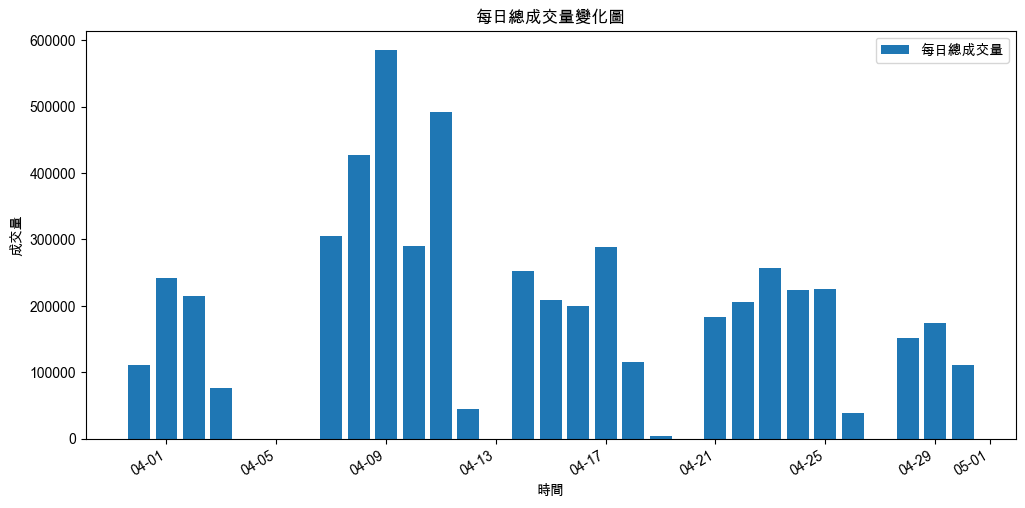

In [48]:
eda_analyzer.plot_daily_volume(df)

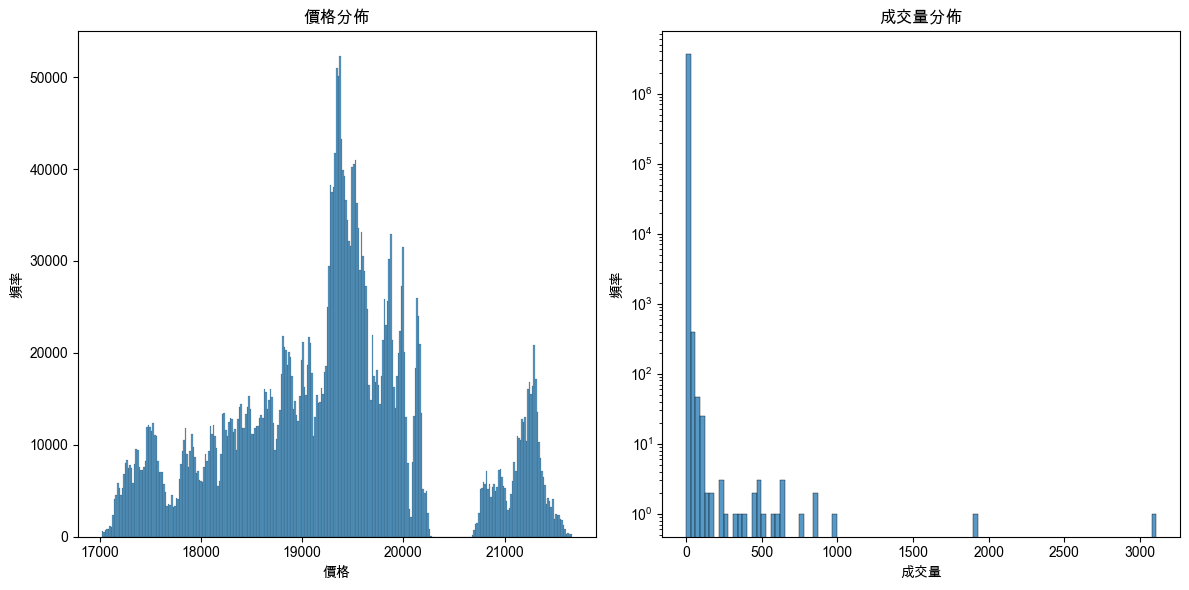

In [49]:
eda_analyzer.plot_price_volume_distribution(df)

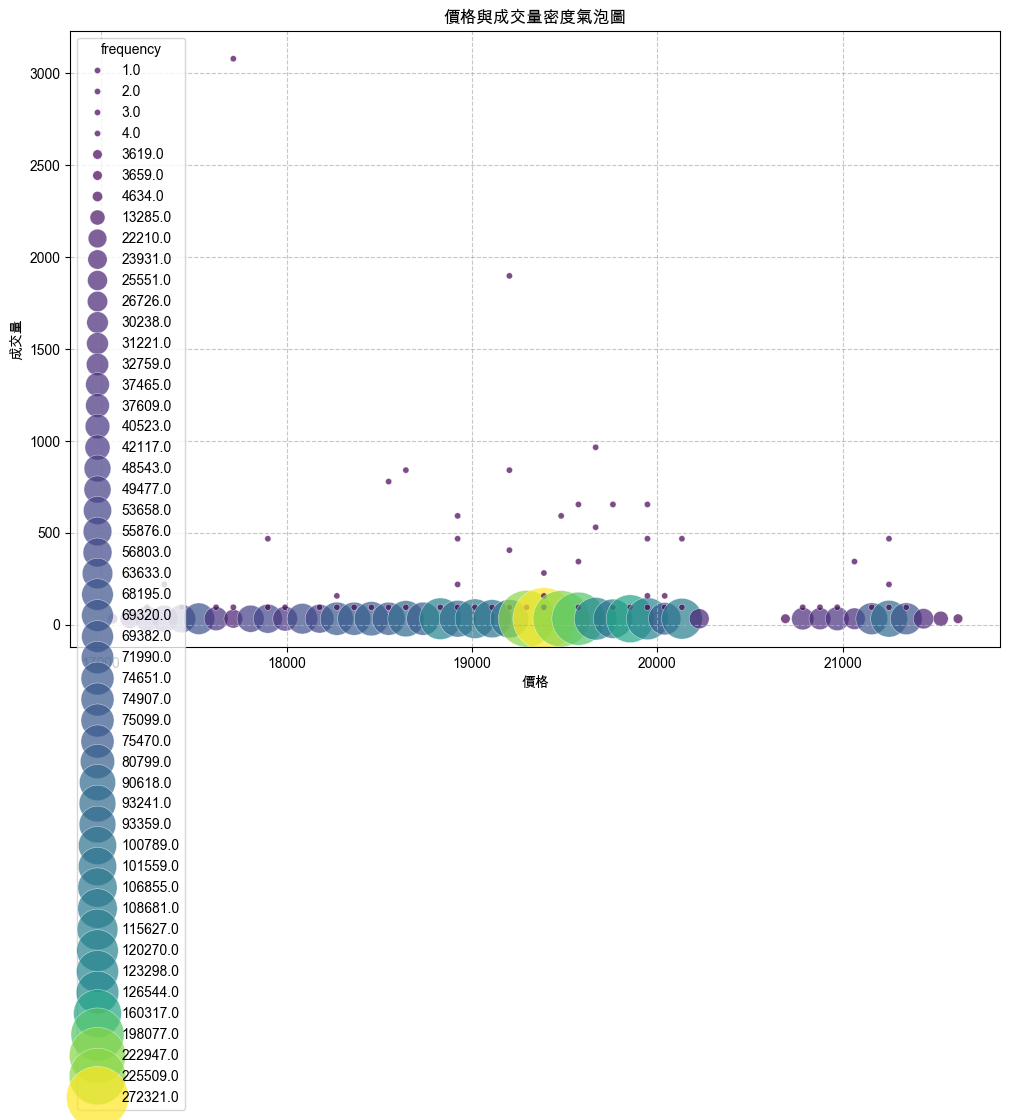

In [50]:
eda_analyzer.plot_price_volume_scatter(df)

# 技術指標特徵工程 (基礎)

計算基礎的技術指標作為初步特徵。

In [51]:
import pandas as pd
from features import feature_engineering

# 假設 df 已經載入並經過清洗和時間序列處理
# 如果您還沒有 df，可以先執行以下範例來創建一個模擬的 DataFrame
# 實際應用中，df 應該是從您的資料載入流程中獲取
# 例如：
# from utils.data_loader import load_and_inspect_data
# from utils.data_cleaner import clean_data, process_time_series
# data_path = '../data/ticks_2025-04.parquet'
# df = load_and_inspect_data(data_path)
# df = clean_data(df)
# df = process_time_series(df)

print("\n開始計算技術指標特徵...")

# 計算簡單移動平均 (SMA)
df['SMA_20'] = feature_engineering.calculate_sma(df['close'], window=20)

# 計算指數移動平均 (EMA)
df['EMA_20'] = feature_engineering.calculate_ema(df['close'], window=20)

# 計算相對強弱指數 (RSI)
df['RSI_14'] = feature_engineering.calculate_rsi(df['close'], window=14)

# 計算布林通道 (Bollinger Bands)
bollinger_bands = feature_engineering.calculate_bollinger_bands(df['close'], window=20, num_std_dev=2)
df = pd.concat([df, bollinger_bands], axis=1)

print("\n新增技術指標特徵後：")
print(df.head())
print(df.tail())
print(f"資料欄位：{df.columns.tolist()}")
len(df)
# df.info()


開始計算技術指標特徵...

新增技術指標特徵後：
                                   ts    close  volume  bid_price  bid_volume  \
timestamp                                                                       
2025-03-31 15:00:00.021  1.743433e+18  20807.0    89.0        0.0         0.0   
2025-03-31 15:00:00.045  1.743433e+18  20808.0     2.0    20807.0         5.0   
2025-03-31 15:00:00.051  1.743433e+18  20809.0     1.0    20807.0         5.0   
2025-03-31 15:00:00.118  1.743433e+18  20807.0     1.0    20807.0         5.0   
2025-03-31 15:00:00.176  1.743433e+18  20807.0     1.0    20807.0         6.0   

                         ask_price  ask_volume  tick_type  is_traffic_limited  \
timestamp                                                                       
2025-03-31 15:00:00.021        0.0         0.0        1.0               False   
2025-03-31 15:00:00.045    20808.0         2.0        1.0               False   
2025-03-31 15:00:00.051    20808.0         2.0        1.0               False   


3623462

# 製作標註欄位 (Target Labeling)

定義預測目標並創建對應的標註欄位。

In [52]:
import importlib
import pandas as pd
from features import labeling

# 重新載入模組
importlib.reload(labeling)

# 呼叫你的函式，window 自行設定，例如 "30min"
labels = labeling.label_future_returns_fast(df['close'], future_window='10min')
# labels = labeling.label_future_returns_turning_point(df['close'], future_window='30min')

# 將標籤放回 df
df["label"] = labels

In [53]:
import plotly.graph_objects as go

# 假設df已經有index是datetime且有'close', 'label'

# 依時間重採樣，取每5分鐘的第一筆資料
df_resampled = df.resample('1min').first().dropna()

fig = go.Figure()

# 價格線（重採樣後）
fig.add_trace(go.Scatter(
    x=df_resampled.index,
    y=df_resampled['close'],
    mode='lines',
    name='Close Price',
    line=dict(color='lightgray'),
    hovertemplate='時間: %{x}<br>價格: %{y:.2f}<extra></extra>'
))

# 挑出三類標籤的點（重採樣後）
up_df = df_resampled[df_resampled['label'] == 1]
down_df = df_resampled[df_resampled['label'] == -1]
neu_df = df_resampled[df_resampled['label'] == 0]

# 標籤1：向上三角形，綠色
fig.add_trace(go.Scattergl(
    x=up_df.index, y=up_df['close'],
    mode='markers',
    name='Up (1)',
    marker=dict(symbol='triangle-up', color='green', size=8),
    hovertemplate='時間: %{x}<br>價格: %{y:.2f}<extra></extra>'
))

# 標籤-1：向下三角形，紅色
fig.add_trace(go.Scattergl(
    x=down_df.index, y=down_df['close'],
    mode='markers',
    name='Down (-1)',
    marker=dict(symbol='triangle-down', color='red', size=8),
    hovertemplate='時間: %{x}<br>價格: %{y:.2f}<extra></extra>'
))

# 標籤0：圓點，灰色
fig.add_trace(go.Scattergl(
    x=neu_df.index, y=neu_df['close'],
    mode='markers',
    name='Neutral (0)',
    marker=dict(symbol='circle', color='gray', size=4),
    hovertemplate='時間: %{x}<br>價格: %{y:.2f}<extra></extra>'
))

fig.update_layout(
    title='Tick 價格走勢與三分類標籤（依時間間隔取樣）',
    xaxis_title='時間',
    yaxis_title='價格',
    legend=dict(orientation='h', y=1.02, x=1),
    hovermode='x unified',
    margin=dict(l=40, r=20, t=60, b=40)
)

fig.show()
print(df['label'].value_counts())
df_resampled.to_parquet('../data/processed/ticks_2025-0527_with_features.parquet', index=False)
len(df_resampled)

label
 0    1992810
 1     818696
-1     811956
Name: count, dtype: int64


22480

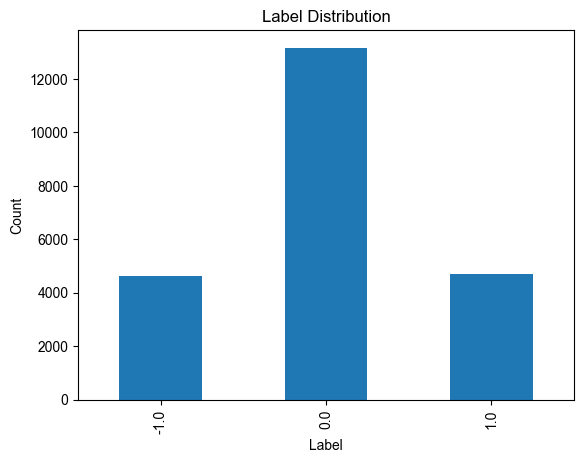

In [54]:
import matplotlib.pyplot as plt

# 先計數
label_counts = df_resampled['label'].value_counts().sort_index()

# 確保 -1, 0, 1 都在，即使數量是 0
for lbl in [-1, 0, 1]:
    if lbl not in label_counts:
        label_counts[lbl] = 0

# 按順序排序（避免順序亂掉）
label_counts = label_counts.sort_index()

# 畫圖
label_counts.plot(kind='bar')

plt.title('Label Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

In [55]:
import pandas as pd

# df_test = pd.read_parquet('../data/processed/ticks_2025-0527_with_features.parquet')
df_test = pd.read_parquet('../data/processed/ticks_2025-04_with_features.parquet')

# print(df.head())
# print(df.shape)

len(df_test)

print(df_test['label'].value_counts())

label
 0.0    13167
 1.0     4691
-1.0     4622
Name: count, dtype: int64
